In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Install dependencies (run once if needed) ──────────────────────────────
# !pip install tensorflow pillow matplotlib numpy scikit-learn

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.19.0
All libraries imported successfully.


---
## Section 2.1 — Data Understanding and Visualizations
---

In [2]:
import zipfile

# ── CONFIGURE THESE PATHS ──────────────────────────────────────────────────
ZIP_FILE_PATH = "/content/FruitinAmazon.zip"
EXTRACT_DIR   = "/content/FruitinAmazon"

# Image and training hyper-parameters
IMAGE_SIZE  = (224, 224)   # VGG16 expects 224×224
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
NUM_CLASSES = 6            # acai, cupuacu, graviola, guarana, pupunha, tucuma

print(f"Zip file path : {ZIP_FILE_PATH}")
print(f"Extract directory: {EXTRACT_DIR}")

Zip file path : /content/FruitinAmazon.zip
Extract directory: /content/FruitinAmazon


### Cell 3: Step 1 — Read Dataset Directory & Extract Class Names

In [ ]:
import zipfile

# ── Extract the dataset if not already extracted ──────────────────────────
if not os.path.exists(EXTRACT_DIR) or not os.listdir(EXTRACT_DIR):
    print(f"Extracting {ZIP_FILE_PATH} to {EXTRACT_DIR}...")
    with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete.")
else:
    print(f"Dataset already extracted to {EXTRACT_DIR}.")

# ── Update BASE_DIR, train_dir, and test_dir to point to the extracted data ──
# Correcting BASE_DIR to account for the extra 'FruitinAmazon' subdirectory after extraction
BASE_DIR  = os.path.join(EXTRACT_DIR, "FruitinAmazon")
train_dir = os.path.join(BASE_DIR, "train")
test_dir  = os.path.join(BASE_DIR, "test")

print(f"Updated BASE_DIR : {BASE_DIR}")
print(f"Updated Train dir: {train_dir}")
print(f"Updated Test  dir: {test_dir}")

# ── Read class names from sub-folder names ─────────────────────────────────
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Extracting /content/drive/MyDrive/Bipin/AIML/FruitinAmazon.zip to /content/FruitinAmazon...
Extraction complete.
Updated BASE_DIR : /content/FruitinAmazon/FruitinAmazon
Updated Train dir: /content/FruitinAmazon/FruitinAmazon/train
Updated Test  dir: /content/FruitinAmazon/FruitinAmazon/test
Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
# ── Inspect the extracted directory structure ─────────────────────────────
print(f"Contents of {EXTRACT_DIR}:")
for item in os.listdir(EXTRACT_DIR):
    print(f"- {item}")


Contents of /content/FruitinAmazon:
- FruitinAmazon


### Cell 4: Step 2 — Check for Corrupted Images

In [ ]:
# ── Detect and remove corrupted images ────────────────────────────────────
corrupted_images = []   # will store paths of bad images

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()          # verify integrity without decoding
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Report results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(" ", img)
    # Optionally delete them:
    # for img in corrupted_images:
    #     os.remove(img)
    # print("\nAll corrupted images removed.")
else:
    print("\nNo corrupted images found.")


No corrupted images found.


### Cell 5: Step 3 — Count Class Balance (Distribution)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


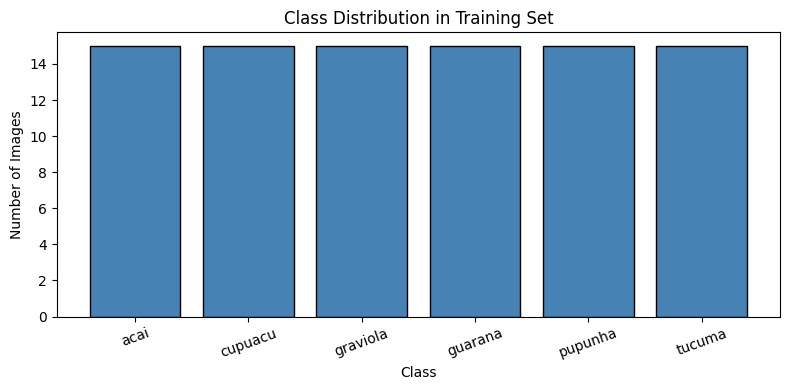

In [ ]:
# ── Count valid images per class ───────────────────────────────────────────
VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg')
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(VALID_EXTENSIONS)
        ]
        class_counts[class_name] = len(images)

# Print formatted table
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)

# Bar chart of class distribution
plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Cell 6: Step 4 — Select & Display Random Images from Each Class

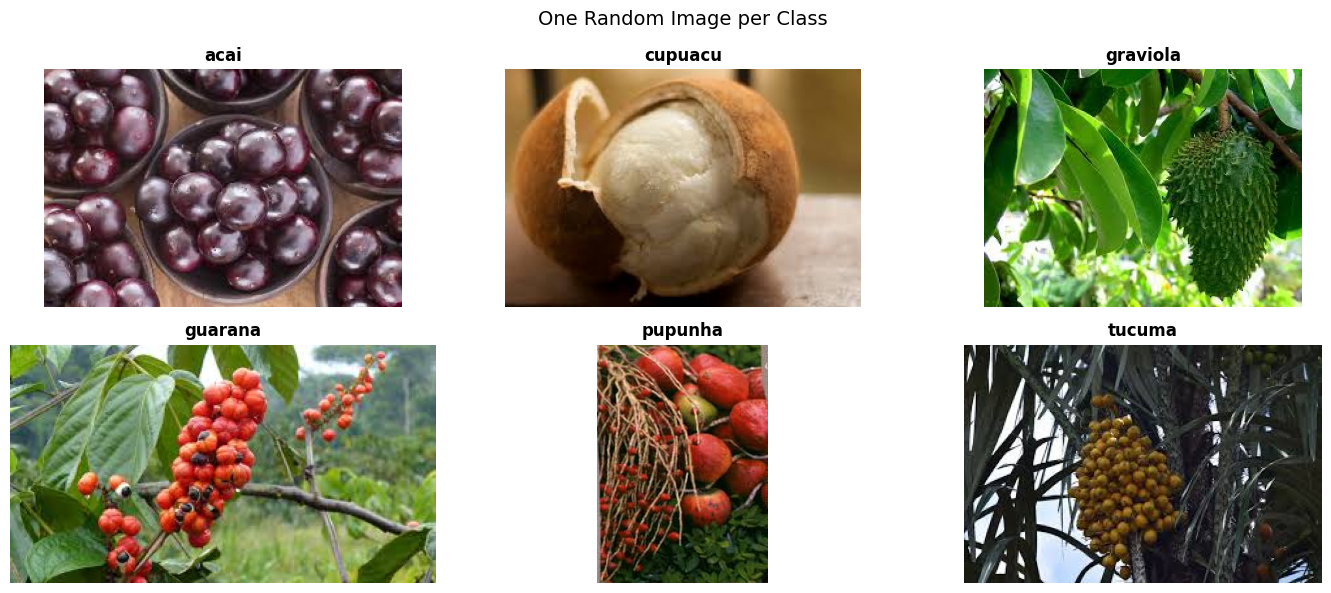

In [ ]:
# ── Select one random image per class ─────────────────────────────────────
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(VALID_EXTENSIONS)
        ]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# ── Plot in grid ───────────────────────────────────────────────────────────
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i], fontsize=12, fontweight='bold')
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("One Random Image per Class", fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 2.2 — Data Generation and Pre-processing
---

### Cell 7: Generate Train and Validation Datasets

In [ ]:
# ── Create train / validation tf.data.Dataset objects ─────────────────────
# 80% training, 20% validation split from the train directory.

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=IMAGE_SIZE,   # (224, 224)
    batch_size=BATCH_SIZE,
)

# Inspect shape of one batch
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)   # (32, 224, 224, 3)
    print("Labels shape:", labels.shape)   # (32,)

print(f"\nClass names from dataset: {train_ds.class_names}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (32, 224, 224, 3)
Labels shape: (32,)

Class names from dataset: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Cell 8: Visualise a Batch from the Training Dataset

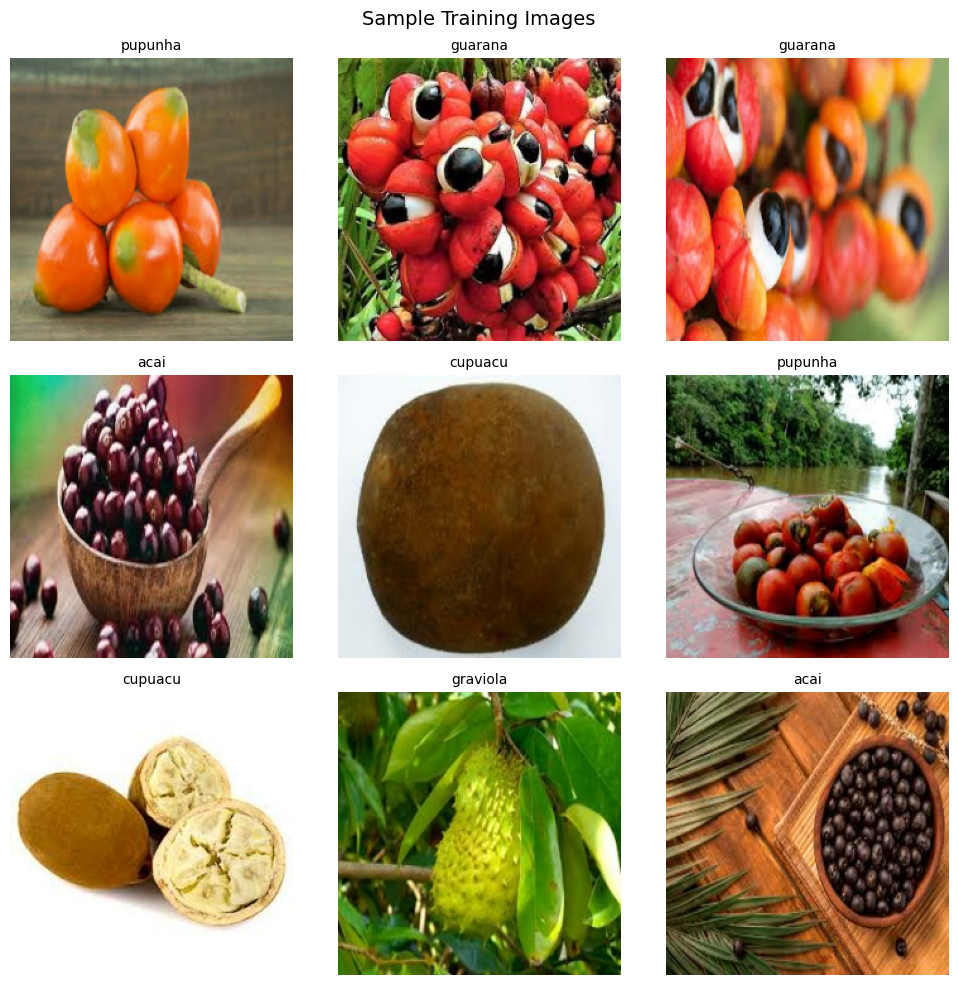

In [ ]:
# ── Visualise 9 sample images from one training batch ─────────────────────
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):      # take one batch
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(train_ds.class_names[int(labels[i])], fontsize=10)
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

### Cell 9: Define Data Augmentation Layers (New Keras API)

In [ ]:
# ── Data Augmentation using tf.keras.layers.Random* (New API) ─────────────
# Applied INSIDE the model so augmentation runs on GPU during model.fit().
# It is automatically disabled during evaluate() and predict().

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),          # horizontal reflection
    layers.RandomRotation(0.15),              # ±15% rotation
    layers.RandomZoom(0.1),                   # ±10% zoom
    layers.RandomTranslation(0.1, 0.1),       # ±10% shift in both axes
    layers.RandomContrast(0.1),               # slight contrast variation
]

def data_augmentation(images):
    """Apply all augmentation layers sequentially."""
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

print("Data augmentation pipeline defined.")

Data augmentation pipeline defined.


### Cell 10: Visualise Augmented Images

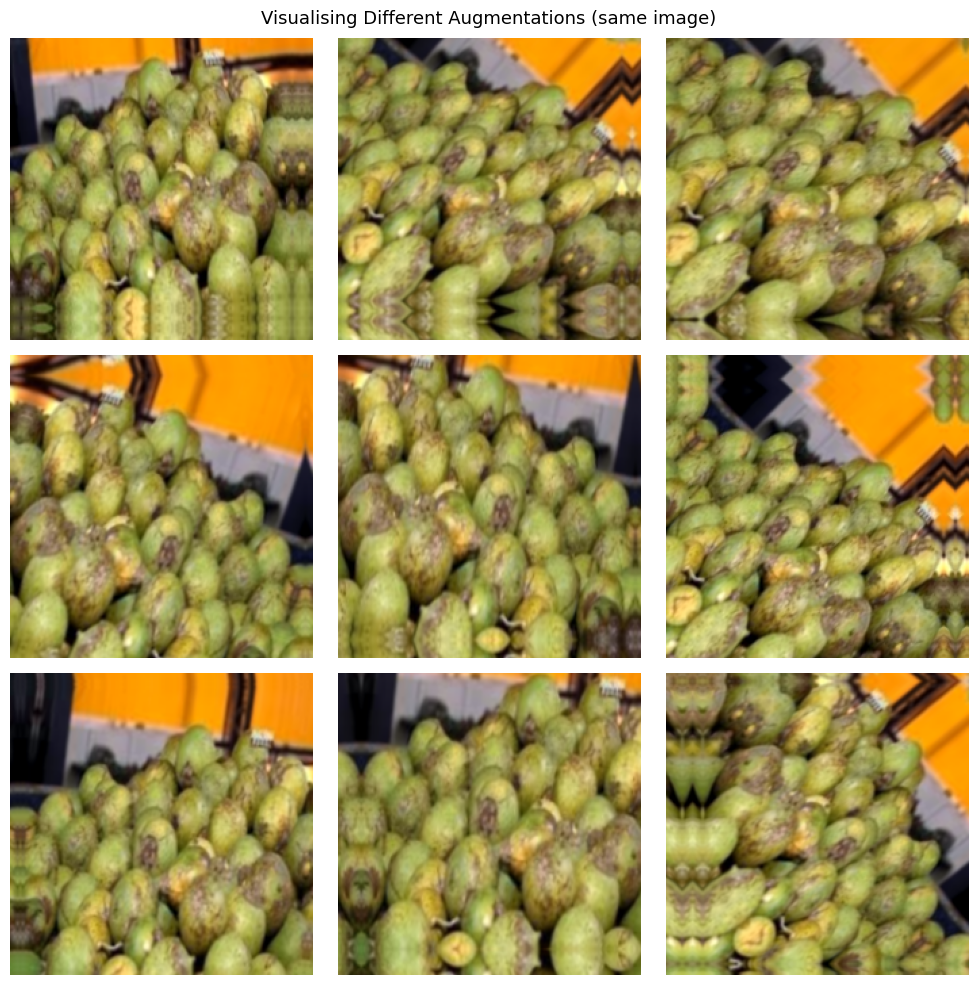

In [ ]:
# ── Show 9 augmented versions of a single batch ────────────────────────────
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Visualising Different Augmentations (same image)", fontsize=13)
plt.tight_layout()
plt.show()

### Cell 11: Performance Optimisation — Prefetch & Cache Datasets

In [ ]:
import tensorflow as tf

# ── Apply data augmentation to the training dataset ────────────────────────
def augment(image, label):
    image = data_augmentation(image) # Apply augmentation layers
    return image, label

train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

# ── Optimise I/O pipeline ─────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets cached and prefetched for optimal GPU utilisation.")

Datasets cached and prefetched for optimal GPU utilisation.


---
## TASK 1 — Custom CNN with BatchNormalization & Dropout
*(Improved model from Worksheet 5)*
---

### Cell 12: Build the Improved Custom CNN Model

In [ ]:
# ── Custom CNN: data augmentation + BN + Dropout ───────────────────────────
# Architecture:
#   Input → Augmentation → Rescaling
#   → Conv Block 1 (32)  → BN → ReLU → MaxPool → Dropout(0.25)
#   → Conv Block 2 (64)  → BN → ReLU → MaxPool → Dropout(0.25)
#   → Conv Block 3 (128) → BN → ReLU → MaxPool → Dropout(0.25)
#   → Conv Block 4 (256) → BN → ReLU → MaxPool → Dropout(0.25)
#   → Flatten
#   → FC 512 → BN → ReLU → Dropout(0.5)
#   → FC 256 → BN → ReLU → Dropout(0.5)
#   → FC 128 → BN → ReLU → Dropout(0.5)
#   → Output (NUM_CLASSES, softmax)

input_shape = IMAGE_SIZE + (3,)   # (224, 224, 3)

cnn_model = Sequential([
    # ── Input ──────────────────────────────────────────────────────────────
    layers.Input(shape=input_shape),

    # ── Pixel Rescaling: [0,255] → [0,1] ──────────────────────────────────
    layers.Rescaling(1. / 255),

    # ── Conv Block 1 ──────────────────────────────────────────────────────
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 2 ──────────────────────────────────────────────────────
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 3 ──────────────────────────────────────────────────────
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 4 ──────────────────────────────────────────────────────
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Flatten ────────────────────────────────────────────────────────────
    Flatten(),

    # ── Fully Connected Block 1 ────────────────────────────────────────────
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Fully Connected Block 2 ────────────────────────────────────────────
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Fully Connected Block 3 ────────────────────────────────────────────
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Output Layer ──────────────────────────────────────────────────────
    Dense(NUM_CLASSES, activation='softmax')
], name="Custom_CNN")

# Print architecture summary
cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    25,690,62

 Total params: 26,249,542 (100.13 MB)

 Trainable params: 26,246,790 (100.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

### Cell 13: Compile the Custom CNN

In [ ]:
# ── Compile ────────────────────────────────────────────────────────────────
# sparse_categorical_crossentropy → labels are integers (not one-hot encoded)

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Custom CNN compiled successfully.")

Custom CNN compiled successfully.


### Cell 14: Define Callbacks for Training

In [ ]:
# ── Callbacks ─────────────────────────────────────────────────────────────
# EarlyStopping  : stops training when val_loss stops improving
# ModelCheckpoint: saves the best model weights automatically
# ReduceLROnPlateau: reduces learning rate when training plateaus

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_cnn = keras.callbacks.ModelCheckpoint(
    filepath='best_custom_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks defined.")

Callbacks defined.


### Cell 15: Train the Custom CNN

In [ ]:
# ── Train ──────────────────────────────────────────────────────────────────
print("Training Custom CNN...")

history_cnn = cnn_model.fit(
    train_ds,
    epochs=NUM_EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stop, checkpoint_cnn, reduce_lr],
    verbose=1
)

print("\nTraining complete.")

Training Custom CNN...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2616 - loss: 2.1763  
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 7s/step - accuracy: 0.2222 - loss: 2.1995 - val_accuracy: 0.0556 - val_loss: 1.8351 - learning_rate: 0.0010
Epoch 2/20
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2188 - loss: 2.1321 
Epoch 2: val_accuracy improved from 0.05556 to 0.22222, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 934ms/step - accuracy: 0.2361 - loss: 2.1151 - val_accuracy: 0.2222 - val_loss: 1.7644 - learning_rate: 0.0010
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2546 - loss: 1.8970
Epoch 3: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.2639 - loss: 1.8489 - val_accuracy: 0.2222 - val

### Cell 16: Plot Training History — Custom CNN

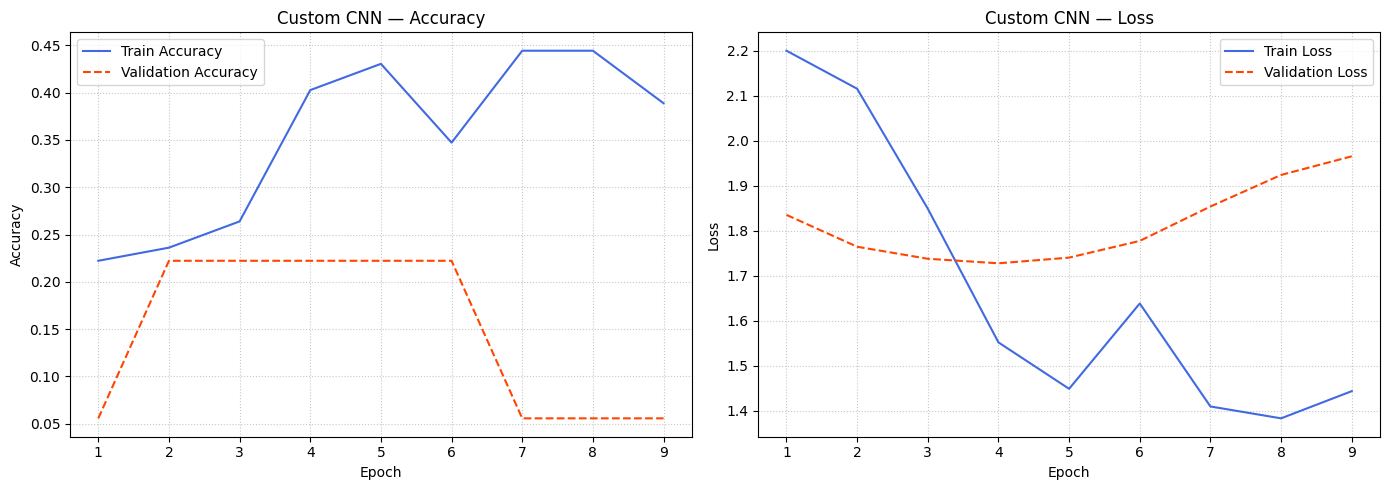

In [ ]:
# ── Helper function: plot accuracy & loss curves ───────────────────────────
def plot_history(history, title="Training History"):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(epochs_range, acc,     label='Train Accuracy',      color='royalblue')
    ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='orangered', linestyle='--')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.7)

    # Loss
    ax2.plot(epochs_range, loss,     label='Train Loss',      color='royalblue')
    ax2.plot(epochs_range, val_loss, label='Validation Loss', color='orangered', linestyle='--')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, title="Custom CNN")

### Cell 17: Evaluate Custom CNN on Validation Set

In [ ]:
# ── Evaluate on validation set ─────────────────────────────────────────────
val_loss_cnn, val_acc_cnn = cnn_model.evaluate(val_ds, verbose=1)
print(f"\nCustom CNN  |  Val Loss: {val_loss_cnn:.4f}  |  Val Accuracy: {val_acc_cnn:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2222 - loss: 1.7277

Custom CNN  |  Val Loss: 1.7277  |  Val Accuracy: 0.2222


### Cell 18: Predict & Generate Classification Report — Custom CNN

In [ ]:
# ── Collect all true labels and predictions from the validation set ────────
y_true_cnn = []
y_pred_cnn = []

for images, labels in val_ds:
    preds = cnn_model.predict(images, verbose=0)
    y_true_cnn.extend(labels.numpy())
    y_pred_cnn.extend(np.argmax(preds, axis=1))

# Classification report
print("\n" + "=" * 60)
print("Classification Report — Custom CNN")
print("=" * 60)
print(classification_report(
    y_true_cnn, y_pred_cnn,
    target_names=class_names
))


Classification Report — Custom CNN
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.22      1.00      0.36         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Cell 19: Confusion Matrix — Custom CNN

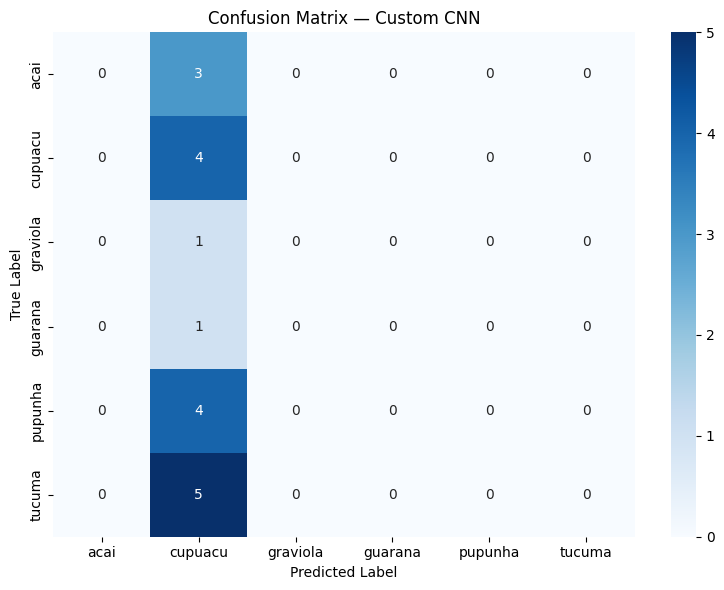

In [ ]:
# ── Confusion matrix helper ────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d',
        xticklabels=class_names,
        yticklabels=class_names,
        cmap='Blues'
    )
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true_cnn, y_pred_cnn, class_names, title="Confusion Matrix — Custom CNN")

### Cell 20: Visualise Sample Predictions — Custom CNN

In [ ]:
# ── Show 9 sample predictions with True vs Predicted labels ───────────────
def show_predictions(model, dataset, class_names, n=9, title="Sample Predictions"):
    plt.figure(figsize=(12, 12))
    count = 0
    for images, labels in dataset.take(1):
        preds = model.predict(images, verbose=0)
        for i in range(min(n, len(images))):
            ax = plt.subplot(3, 3, count + 1)
            plt.imshow(np.array(images[i]).astype("uint8"))
            true_label = class_names[np.argmax(labels[i])] # Fixed: use np.argmax for one-hot encoded labels
            pred_label = class_names[np.argmax(preds[i])]
            confidence  = np.max(preds[i]) * 100
            color = 'green' if true_label == pred_label else 'red'
            ax.set_title(
                f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                color=color, fontsize=9
            )
            ax.axis("off")
            count += 1
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### Cell 21: Save the Custom CNN Model

In [ ]:
# ── Save trained model ─────────────────────────────────────────────────────
cnn_model.save("custom_cnn_final.keras")
print("Custom CNN saved to 'custom_cnn_final.keras'")

# To reload later:
# loaded_model = keras.models.load_model('custom_cnn_final.keras')

Custom CNN saved to 'custom_cnn_final.keras'


---
## TASK 2 — Transfer Learning with VGG16 (Fine-tuning)
---

### Cell 22: Prepare Datasets for VGG16
> VGG16 requires **224×224 RGB** input — already configured above.

In [ ]:
# ── Re-create datasets for VGG16 (in case kernel was restarted) ───────────
# VGG16 needs images scaled to [0,1] or pre-processed with
# tf.keras.applications.vgg16.preprocess_input.
# We will apply VGG16's own pre-processing inside the model.

train_ds_vgg, val_ds_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=IMAGE_SIZE,      # (224, 224)
    batch_size=BATCH_SIZE,
    label_mode='categorical',   # one-hot labels for categorical_crossentropy
)

# Store class names before caching/prefetching
vgg_class_names = train_ds_vgg.class_names

AUTOTUNE = tf.data.AUTOTUNE

# Apply augmentation to training dataset for VGG16 as well
def augment_vgg(image, label):
    image = data_augmentation(image) # Re-use the defined augmentation pipeline
    return image, label

train_ds_vgg = train_ds_vgg.map(augment_vgg, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_vgg = train_ds_vgg.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds_vgg   = val_ds_vgg.cache().prefetch(AUTOTUNE)

print("VGG16 datasets ready.")
print("Class names:", vgg_class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
VGG16 datasets ready.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Cell 23: Step 1 — Load Pre-trained VGG16 Base (without top)

In [ ]:
# ── Load VGG16 pre-trained on ImageNet, excluding the classification head ──
base_model = VGG16(
    weights='imagenet',
    include_top=False,           # exclude original FC layers
    input_shape=IMAGE_SIZE + (3,)  # (224, 224, 3)
)

print(f"VGG16 base model loaded.")
print(f"Total layers in base model: {len(base_model.layers)}")
base_model.summary()

VGG16 base model loaded.
Total layers in base model: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Cell 24: Step 2 — Freeze All Base Model Layers

In [ ]:
# ── Freeze base model layers ───────────────────────────────────────────────
# Prevents the pre-trained ImageNet weights from being overwritten.

for layer in base_model.layers:
    layer.trainable = False

# Verify — count trainable vs non-trainable parameters
trainable_params     = sum(tf.size(w).numpy() for w in base_model.trainable_weights)
non_trainable_params = sum(tf.size(w).numpy() for w in base_model.non_trainable_weights)
print(f"Trainable params     : {trainable_params:,}")
print(f"Non-trainable params : {non_trainable_params:,}")

Trainable params     : 0
Non-trainable params : 14,714,688


### Cell 25: Step 3 — Add VGG16 Pre-processing + Augmentation + Custom Classification Head

In [ ]:
# ── Build the full transfer learning model using the Functional API ────────

# Input
inputs = keras.Input(shape=IMAGE_SIZE + (3,))   # (224, 224, 3)

# VGG16-specific pre-processing: scales pixels to [-1, 1] as expected by VGG16
# Augmentation is now applied at the dataset level (CPU).
x = tf.keras.applications.vgg16.preprocess_input(inputs)

# Frozen VGG16 feature extractor
x = base_model(x, training=False)   # training=False keeps BN layers in inference mode

# Global Average Pooling: converts feature maps → 1D vector
x = GlobalAveragePooling2D()(x)

# Custom classification head
x = Dense(1024, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(512, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

# Output: one neuron per class with softmax
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Assemble model
vgg_model = Model(inputs=inputs, outputs=outputs, name="VGG16_Transfer")

vgg_model.summary()

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ input_layer_6[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ input_layer_6[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ input_layer_6[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[1][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1024)      │    525,312 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 1024)      │          0 │ activation_18[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 512)       │    524,800 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 512)       │          0 │ activation_19[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 6)         │      3,078 │ dropout_19[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,774,022 (60.17 MB)

 Trainable params: 8,135,686 (31.04 MB)

 Non-trainable params: 7,638,336 (29.14 MB)

### Cell 26: Step 5 — Compile & Train the VGG16 Transfer Learning Model

In [ ]:
# ── Compile ────────────────────────────────────────────────────────────────
# categorical_crossentropy → labels are one-hot encoded (label_mode='categorical')

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),   # small LR — only new layers being trained
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_vgg = keras.callbacks.ModelCheckpoint(
    filepath='best_vgg16_transfer.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_vgg = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ── Train (Phase 1: head only) ─────────────────────────────────────────────
print("Phase 1: Training custom head only (base frozen)...")

history_vgg = vgg_model.fit(
    train_ds_vgg,
    epochs=NUM_EPOCHS,
    validation_data=val_ds_vgg,
    callbacks=[early_stop_vgg, checkpoint_vgg, reduce_lr_vgg],
    verbose=1
)

print("\nPhase 1 training complete.")

Phase 1: Training custom head only (base frozen)...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1343 - loss: 2.5050
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_vgg16_transfer.keras

Epoch 1: finished saving model to best_vgg16_transfer.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 9s/step - accuracy: 0.1528 - loss: 2.5581 - val_accuracy: 0.1111 - val_loss: 3.7835 - learning_rate: 1.0000e-04
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.3144 - loss: 1.9745
Epoch 2: val_accuracy improved from 0.11111 to 0.27778, saving model to best_vgg16_transfer.keras

Epoch 2: finished saving model to best_vgg16_transfer.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 479ms/step - accuracy: 0.3056 - loss: 1.8574 - val_accuracy: 0.2778 - val_loss: 2.9944 - learning_rate: 1.0000e-04
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4743 - loss: 1.4801
Epoch 3: val_accuracy improved from 0.27778 to 0.33333, saving model to best_vgg16_transfer.keras

E

### Cell 27: (Optional) Phase 2 — Fine-tune Top VGG16 Layers

In [ ]:
# ── Phase 2: Unfreeze last 4 conv layers of VGG16 for fine-tuning ─────────
# This allows the model to adapt the high-level VGG16 features to our dataset.

print("\nPhase 2: Fine-tuning last 4 layers of VGG16...")

# Unfreeze the top layers of the base model
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Re-compile with a very low learning rate
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = vgg_model.fit(
    train_ds_vgg,
    epochs=10,
    validation_data=val_ds_vgg,
    callbacks=[early_stop_vgg, checkpoint_vgg, reduce_lr_vgg],
    verbose=1
)

print("\nPhase 2 (fine-tuning) complete.")


Phase 2: Fine-tuning last 4 layers of VGG16...
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9954 - loss: 0.0995
Epoch 1: val_accuracy improved from 0.50000 to 0.55556, saving model to best_vgg16_transfer.keras

Epoch 1: finished saving model to best_vgg16_transfer.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9861 - loss: 0.1342 - val_accuracy: 0.5556 - val_loss: 1.3012 - learning_rate: 1.0000e-05
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9324 - loss: 0.1411
Epoch 2: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.9722 - loss: 0.1467 - val_accuracy: 0.5556 - val_loss: 1.1985 - learning_rate: 1.0000e-05
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9824 - loss: 0.1400
Epoch 3: val_accuracy improved from 0.55556 to 0.61111, saving model to best_vgg16_transfer.keras

Epoch 3: finished saving model to best_vgg16_transfer.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - accuracy:

### Cell 28: Plot Training History — VGG16

In [ ]:
plot_history(history_vgg,      title="VGG16 Transfer Learning — Phase 1")
plot_history(history_finetune, title="VGG16 Transfer Learning — Phase 2 Fine-tuning")

### Cell 29: Evaluate VGG16 Transfer Model

In [ ]:
val_loss_vgg, val_acc_vgg = vgg_model.evaluate(val_ds_vgg, verbose=1)
print(f"\nVGG16 Transfer  |  Val Loss: {val_loss_vgg:.4f}  |  Val Accuracy: {val_acc_vgg:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.6111 - loss: 0.9125

VGG16 Transfer  |  Val Loss: 0.9125  |  Val Accuracy: 0.6111


### Cell 30: Predict & Generate Classification Report — VGG16

In [ ]:
# ── Collect true labels and predictions ───────────────────────────────────
y_true_vgg = []
y_pred_vgg = []

for images, labels in val_ds_vgg:
    preds = vgg_model.predict(images, verbose=0)
    y_true_vgg.extend(np.argmax(labels.numpy(), axis=1))  # one-hot → integer
    y_pred_vgg.extend(np.argmax(preds, axis=1))

# Classification report
print("\n" + "=" * 60)
print("Classification Report — VGG16 Transfer Learning")
print("=" * 60)
print(classification_report(
    y_true_vgg, y_pred_vgg,
    target_names=vgg_class_names
))


Classification Report — VGG16 Transfer Learning
              precision    recall  f1-score   support

        acai       0.50      0.67      0.57         3
     cupuacu       1.00      0.50      0.67         4
    graviola       1.00      1.00      1.00         1
     guarana       0.33      1.00      0.50         1
     pupunha       0.75      0.75      0.75         4
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.61        18
   macro avg       0.68      0.72      0.66        18
weighted avg       0.69      0.61      0.62        18



### Cell 31: Confusion Matrix — VGG16

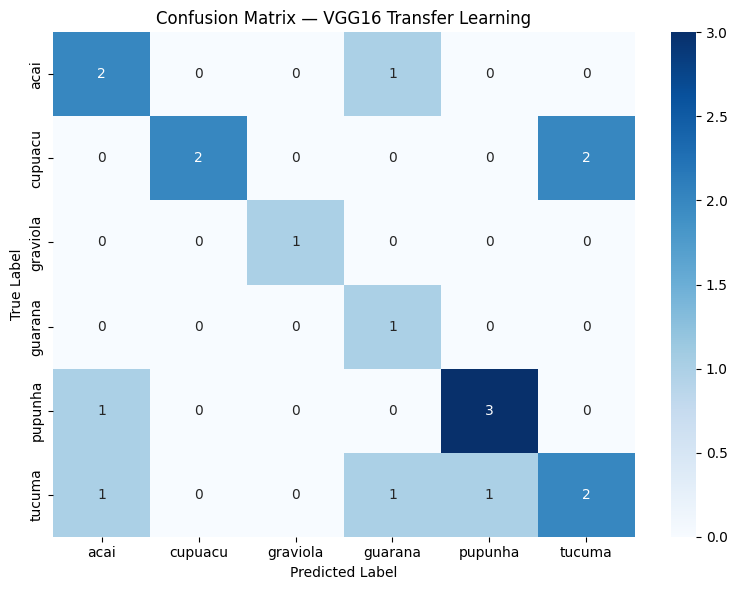

In [ ]:
plot_confusion_matrix(
    y_true_vgg, y_pred_vgg,
    vgg_class_names,
    title="Confusion Matrix — VGG16 Transfer Learning"
)

### Cell 32: Visualise Sample Predictions — VGG16

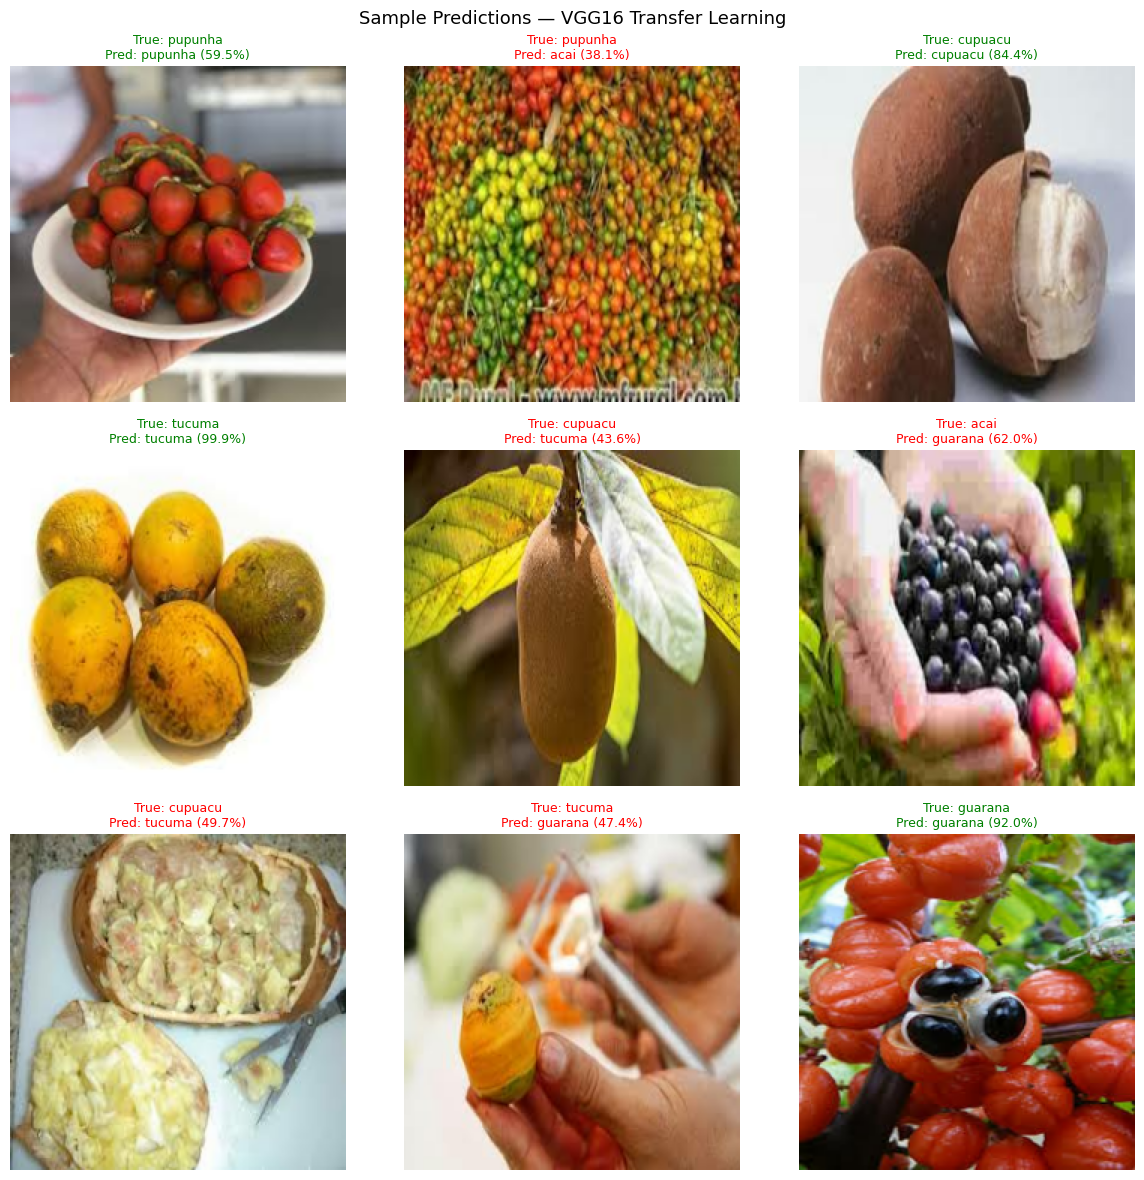

In [ ]:
show_predictions(
    vgg_model, val_ds_vgg,
    vgg_class_names,
    title="Sample Predictions — VGG16 Transfer Learning"
)

### Cell 33: Save the VGG16 Transfer Learning Model

In [ ]:
vgg_model.save("vgg16_transfer_final.keras")
print("VGG16 transfer model saved to 'vgg16_transfer_final.keras'")

VGG16 transfer model saved to 'vgg16_transfer_final.keras'


---
## Model Comparison: Custom CNN vs VGG16 Transfer Learning
---

### Cell 34: Side-by-Side Performance Comparison

In [ ]:
# ── Print summary comparison table ────────────────────────────────────────
print("\n" + "=" * 55)
print(f"{'Model':<30} {'Val Loss':>10} {'Val Acc':>10}")
print("=" * 55)
print(f"{'Custom CNN (from scratch)':<30} {val_loss_cnn:>10.4f} {val_acc_cnn:>10.4f}")
print(f"{'VGG16 Transfer Learning':<30} {val_loss_vgg:>10.4f} {val_acc_vgg:>10.4f}")
print("=" * 55)

improvement = (val_acc_vgg - val_acc_cnn) * 100
if improvement > 0:
    print(f"\n✅ VGG16 Transfer Learning improved accuracy by {improvement:.2f}% over Custom CNN.")
elif improvement < 0:
    print(f"\n⚠️  Custom CNN outperformed VGG16 Transfer Learning by {abs(improvement):.2f}%.")
else:
    print("\n🔵 Both models achieved equal accuracy.")


Model                            Val Loss    Val Acc
Custom CNN (from scratch)          1.7277     0.2222
VGG16 Transfer Learning            0.9125     0.6111

✅ VGG16 Transfer Learning improved accuracy by 38.89% over Custom CNN.


### Cell 35: Bar Chart — Accuracy Comparison

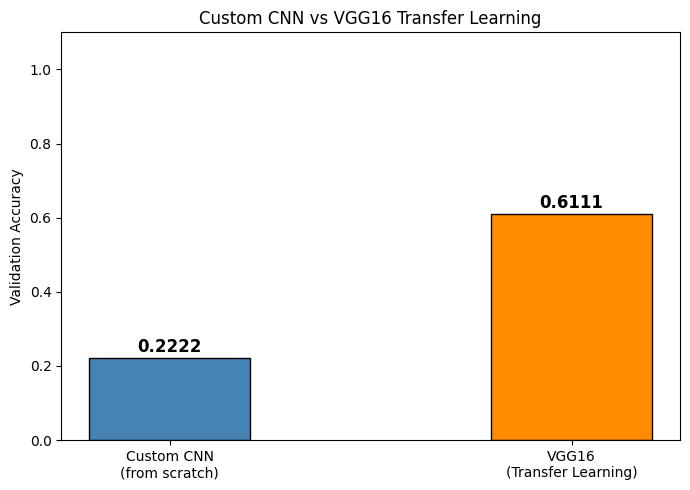

In [ ]:
# ── Visual comparison ──────────────────────────────────────────────────────
models      = ['Custom CNN\n(from scratch)', 'VGG16\n(Transfer Learning)']
accuracies  = [val_acc_cnn, val_acc_vgg]
colors      = ['steelblue', 'darkorange']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{acc:.4f}",
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
plt.ylim(0, 1.1)
plt.ylabel('Validation Accuracy')
plt.title('Custom CNN vs VGG16 Transfer Learning')
plt.tight_layout()
plt.show()

### Cell 36: Overlay Training Curves — Both Models

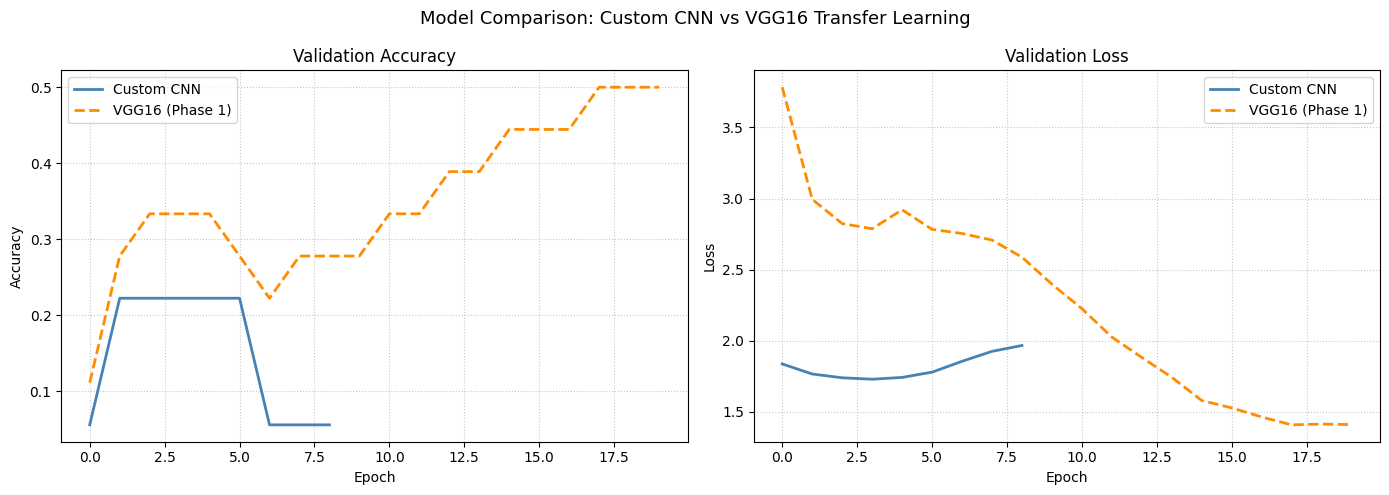

In [ ]:
# ── Overlay val_accuracy of both models ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history_cnn.history['val_accuracy'],
         label='Custom CNN',              color='steelblue',  linewidth=2)
ax1.plot(history_vgg.history['val_accuracy'],
         label='VGG16 (Phase 1)',         color='darkorange', linewidth=2, linestyle='--')
ax1.set_title('Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# Loss
ax2.plot(history_cnn.history['val_loss'],
         label='Custom CNN',              color='steelblue',  linewidth=2)
ax2.plot(history_vgg.history['val_loss'],
         label='VGG16 (Phase 1)',         color='darkorange', linewidth=2, linestyle='--')
ax2.set_title('Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

plt.suptitle('Model Comparison: Custom CNN vs VGG16 Transfer Learning', fontsize=13)
plt.tight_layout()
plt.show()

---
## Conclusion

| Aspect | Custom CNN | VGG16 Transfer Learning |
|---|---|---|
| Pre-trained weights | ❌ None | ✅ ImageNet |
| Training time | Longer | Faster (head only) |
| Data required | More | Less |
| Performance (small dataset) | Lower | Higher |
| Customisation | Full | Head only (Phase 1) |
| Fine-tuning option | N/A | ✅ Phase 2 available |

**Transfer learning with VGG16 generally outperforms a model trained from scratch**, especially on small datasets like FruitsInAmazon (15 images/class), because:
- VGG16 already learned rich low-level features (edges, textures) from 1.2M ImageNet images.
- Only the classification head needs to learn task-specific patterns.
- Less risk of overfitting due to fewer trainable parameters.
---